## =====================================================
# Customer Purchase Prediction from E-commerce Data
# =====================================================


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import precision_recall_curve, auc, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')


 ------------------------------
# 1. LOAD DATA
# ------------------------------
# Download from UCI (or use local file)

In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv"
df = pd.read_csv(url)
print("Data shape:", df.shape)
print(df.head())

Data shape: (12330, 18)
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0   Feb                 1   
1         0.00       0.10         

# ------------------------------
# 2. DATA CLEANING & PREVIEW
# ------------------------------
# Check missing values

In [4]:
print("\nMissing values:\n", df.isnull().sum())

# Separate features and target
X = df.drop('Revenue', axis=1)
y = df['Revenue'].astype(int)  # True/False -> 1/0

# Encode categorical variables
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print("\nCategorical columns:", categorical_cols)

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le



Missing values:
 Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

Categorical columns: ['Month', 'VisitorType']


 ------------------------------
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ------------------------------
# Check class imbalance


Class distribution (Revenue = 1 means purchase):
Revenue
0    0.845255
1    0.154745
Name: proportion, dtype: float64


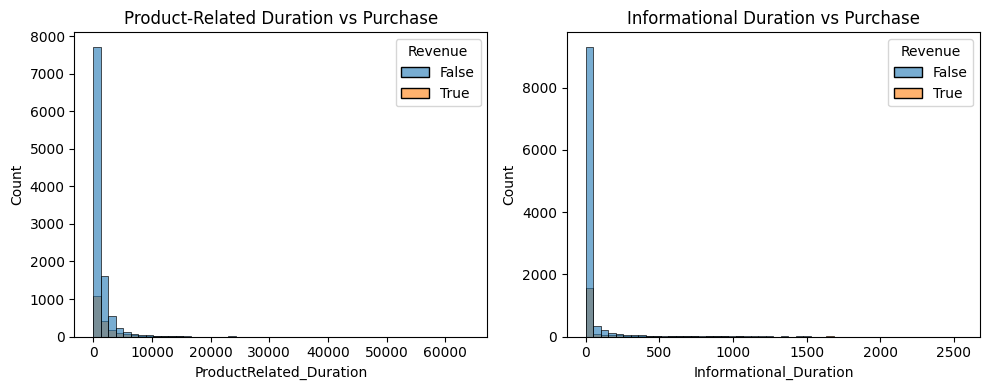

In [5]:
print("\nClass distribution (Revenue = 1 means purchase):")
print(y.value_counts(normalize=True))

# Plot 1: Session duration distribution by purchase
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(data=df, x='ProductRelated_Duration', hue='Revenue', bins=50, alpha=0.6)
plt.title('Product-Related Duration vs Purchase')
plt.subplot(1,2,2)
sns.histplot(data=df, x='Informational_Duration', hue='Revenue', bins=50, alpha=0.6)
plt.title('Informational Duration vs Purchase')
plt.tight_layout()
plt.show()


# Plot 2: Correlation heatmap (top features)

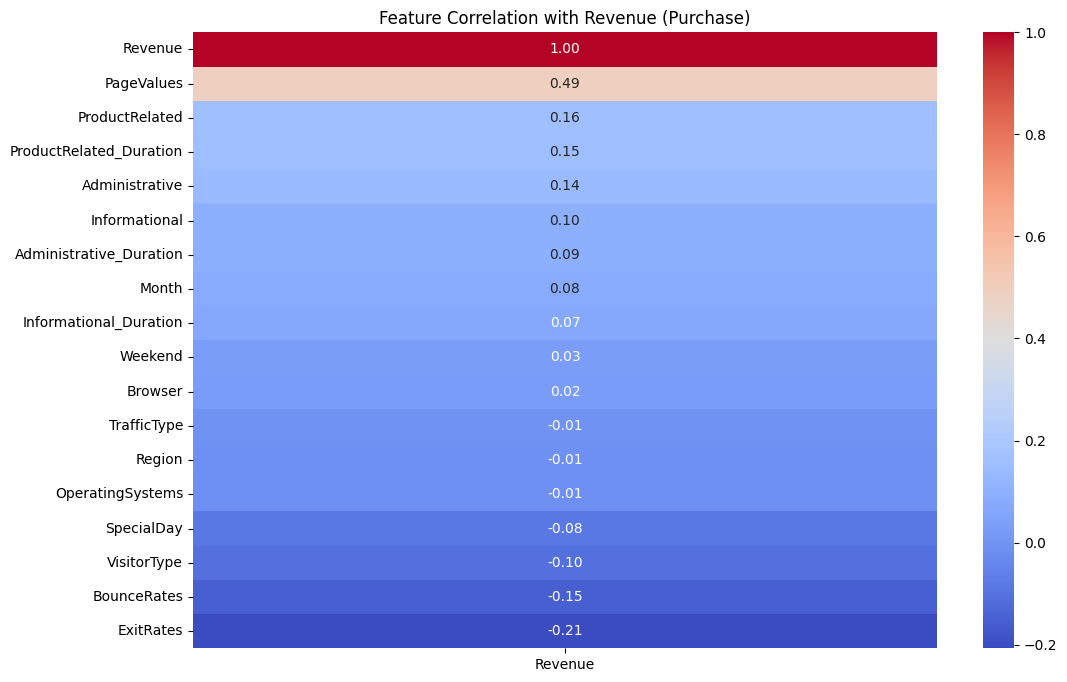

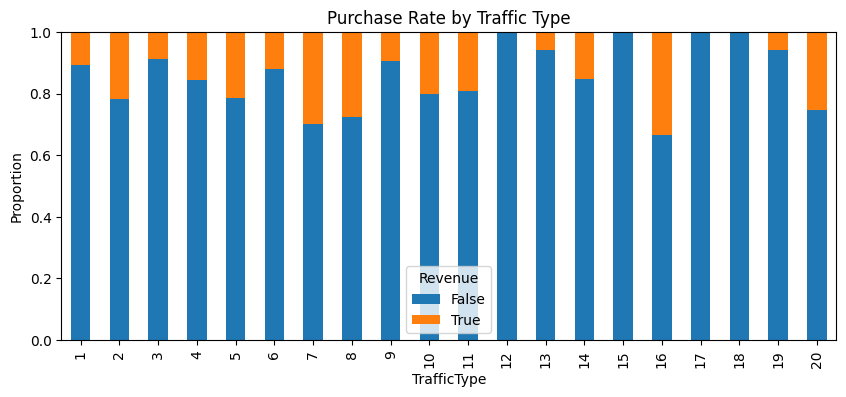

In [6]:
plt.figure(figsize=(12,8))
numeric_df = pd.concat([X, y], axis=1)
corr = numeric_df.corr()
sns.heatmap(corr[['Revenue']].sort_values(by='Revenue', ascending=False), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation with Revenue (Purchase)')
plt.show()

# Plot 3: Traffic type vs purchase
pd.crosstab(df['TrafficType'], df['Revenue'], normalize='index').plot(kind='bar', stacked=True, figsize=(10,4))
plt.title('Purchase Rate by Traffic Type')
plt.ylabel('Proportion')
plt.show()


# ------------------------------
# 4. FEATURE ENGINEERING
# ------------------------------
# Create new features:

X['PagesPerMinute'] = X['PageValues'] / (X['ProductRelated_Duration'] + 1e-5)  # avoid div by zero
X['Weekend'] = X['Weekend'].astype(int)  # already 0/1 but ensure
X['EveningSession'] = ((X['VisitorType'] == 1) & (X['SpecialDay'] > 0.5)).astype(int)  # example custom
 Drop redundant or leaked columns (optional, but keep most)
#We'll keep all except maybe 'Administrative_Duration' if too correlated? No, we keep all.


# ------------------------------
# 5. TRAIN/TEST SPLIT & SCALING
# ------------------------------

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale numerical features (only for logistic regression & XGBoost benefits)
scaler = StandardScaler()
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

# ------------------------------
# 6. HANDLE IMBALANCE (SMOTE)
# ------------------------------


In [8]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
print(f"\nAfter SMOTE: Train shape {X_train_res.shape}, class distribution: {pd.Series(y_train_res).value_counts().to_dict()}")



After SMOTE: Train shape (16676, 17), class distribution: {0: 8338, 1: 8338}


 # ------------------------------
# 7. MODEL TRAINING & EVALUATION
# ------------------------------

In [10]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(random_state=42, scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]), eval_metric='logloss')
}

results = {}
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall, precision)
    y_pred = (y_pred_proba >= 0.5).astype(int)
    results[name] = {
        'PR-AUC': pr_auc,
        'Classification Report': classification_report(y_test, y_pred, target_names=['No Purchase', 'Purchase']),
        'Confusion Matrix': confusion_matrix(y_test, y_pred)
    }
    print(f"\n===== {name} =====")
    print(f"Precision-Recall AUC: {pr_auc:.3f}")
    print(results[name]['Classification Report'])



===== Logistic Regression =====
Precision-Recall AUC: 0.610
              precision    recall  f1-score   support

 No Purchase       0.94      0.89      0.92      2084
    Purchase       0.54      0.72      0.62       382

    accuracy                           0.86      2466
   macro avg       0.74      0.80      0.77      2466
weighted avg       0.88      0.86      0.87      2466


===== Random Forest =====
Precision-Recall AUC: 0.709
              precision    recall  f1-score   support

 No Purchase       0.94      0.92      0.93      2084
    Purchase       0.62      0.70      0.66       382

    accuracy                           0.89      2466
   macro avg       0.78      0.81      0.80      2466
weighted avg       0.89      0.89      0.89      2466


===== XGBoost =====
Precision-Recall AUC: 0.683
              precision    recall  f1-score   support

 No Purchase       0.95      0.89      0.92      2084
    Purchase       0.55      0.72      0.63       382

    accuracy     

# ------------------------------
# 8. FEATURE IMPORTANCE (Random Forest)
# ------------------------------

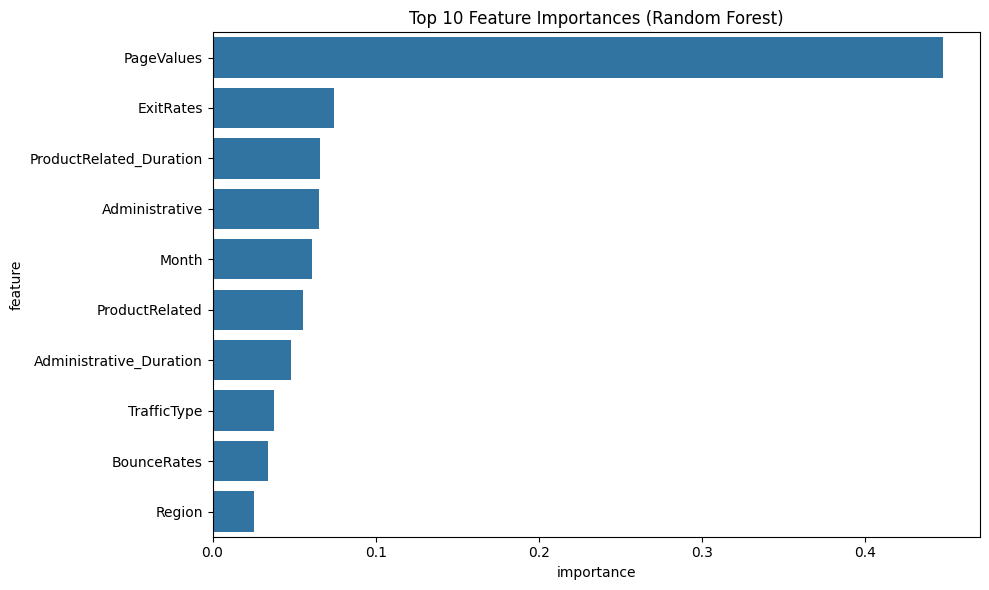


=== Business Insights ===
Top 5 most important features for predicting a purchase:
 - PageValues: 0.448
 - ExitRates: 0.074
 - ProductRelated_Duration: 0.066
 - Administrative: 0.065
 - Month: 0.061

Actionable recommendation: Focus on increasing 'ProductRelated_Duration' and 'PageValues' via personalized recommendations and cross-selling. Retarget visitors from TrafficType=2 (e.g., affiliate traffic) as they have lower purchase rates.



In [11]:
best_model = models['Random Forest']
importances = best_model.feature_importances_
feature_names = X_train_scaled.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance_df.head(10), x='importance', y='feature')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

# Print top 5 features and business insights
print("\n=== Business Insights ===")
print("Top 5 most important features for predicting a purchase:")
for i, row in feature_importance_df.head(5).iterrows():
    print(f" - {row['feature']}: {row['importance']:.3f}")
print("\nActionable recommendation: Focus on increasing 'ProductRelated_Duration' and 'PageValues' via personalized recommendations and cross-selling. Retarget visitors from TrafficType=2 (e.g., affiliate traffic) as they have lower purchase rates.\n")


# ------------------------------
# 9. SAVE RESULTS (optional)
# ------------------------------
# Uncomment to save predictions
# pd.DataFrame({'actual': y_test, 'pred_proba': models['Random Forest'].predict_proba(X_test_scaled)[:,1]}).to_csv('predictions.csv', index=False)